In [17]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 5000

In [25]:
data = {
    "CustomerID" : np.arange(1,n+1),
    'Gender' : np.random.choice(['Male', 'Female'],n),
    'SeniorCitizen' : np.random.choice([0,1],n, p=[0.8,0.2]),
    "Tenure": np.random.randint(1, 72, n),
    'MonthlyCharges' : np.random.uniform(20,120,n).round(2),
    'Contract' : np.random.choice(
        ['Month-to-month', 'One year', 'Two year'],
    n,
    p = [0.6,0.25,0.15]),
    'PaymentMethod' : np.random.choice(
        ["Credit card", "Debit card", "UPI", "Net Banking"], n
    )
}

In [26]:
df = pd.DataFrame(data)

df['TotalCharges'] = (df['Tenure'] * df['MonthlyCharges']).round(2)

In [27]:
def generate_churn(row):
    if row['Contract'] == "Month-to-month" and row["MonthlyCharges"] > 80:
        return 'Yes'
    elif row['Tenure'] < 12:
        return 'Yes'
    elif row['Contract'] == 'Two year':
        return 'No'
    else:
        return np.random.choice(['Yes', 'No'], p=[0.3,0.7])
    
df['Churn'] = df.apply(generate_churn, axis=1)

df.to_csv('customer_churn.csv', index=False)

df.head()
    

,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,Female,0,12,92.02,One year,UPI,1104.24,Yes
1,2,Male,0,62,79.36,One year,Net Banking,4920.32,No
2,3,Female,0,24,91.52,Month-to-month,UPI,2196.48,Yes
3,4,Female,0,2,43.01,One year,Credit card,86.02,Yes
4,5,Female,0,47,100.38,One year,Debit card,4717.86,No


In [28]:
df.shape
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      5000 non-null   int32  
 1   Gender          5000 non-null   object 
 2   SeniorCitizen   5000 non-null   int32  
 3   Tenure          5000 non-null   int32  
 4   MonthlyCharges  5000 non-null   float64
 5   Contract        5000 non-null   object 
 6   PaymentMethod   5000 non-null   object 
 7   TotalCharges    5000 non-null   float64
 8   Churn           5000 non-null   object 
dtypes: float64(2), int32(3), object(4)
memory usage: 293.1+ KB


Yes    2569
No     2431
Name: Churn, dtype: int64

In [29]:
# Check missing
df.isnull().sum()

CustomerID        0
Gender            0
SeniorCitizen     0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [30]:
df['TotalCharges'] = (df['Tenure'] * df['MonthlyCharges']).round(2)

# convert data type replace empty to Nan (errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [31]:
# Average charge per month
df["AvgCharges"] = df["TotalCharges"] / df["Tenure"]

# Senior citizen flag
df["IsSenior"] = df["SeniorCitizen"].apply(lambda x: 1 if x == 1 else 0)

# EDA (Exploratory Data Analysis)

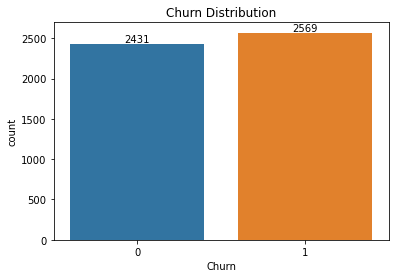

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

#Churn Distribution
ax = sns.countplot(x="Churn", data=df)

ax.bar_label(ax.containers[0])

plt.title("Churn Distribution")
plt.show()

Churn by Contract

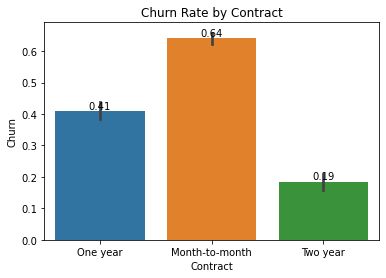

In [37]:
ax = sns.barplot(x="Contract", y="Churn", data=df)

ax.bar_label(ax.containers[0], fmt="%.2f") #formats values to 2 decimal

plt.title("Churn Rate by Contract")
plt.show()

Monthly Charges vs Churn

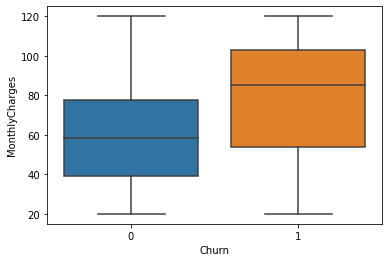

In [39]:
ax = sns.boxplot(x='Churn',y="MonthlyCharges", data=df)

plt.show()

# Tenure vs Churn

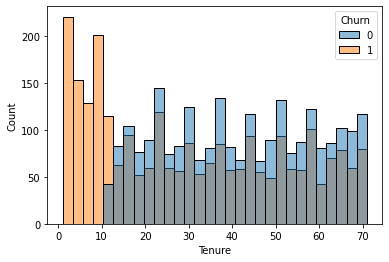

In [40]:
sns.histplot(data=df, x="Tenure", hue="Churn", bins=30)
plt.show()

# Machine Learning

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Convert categorical variables
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.726


In [42]:
df["Churn"].value_counts(normalize=True)

1    0.5138
0    0.4862
Name: Churn, dtype: float64